In [243]:
import pandas as pd
import numpy as np
import os

df_final =pd.read_csv("../data/final/accident_ml_data.csv")
print(df_final.shape)
print(df_final.columns)

(4473, 20)
Index(['Unnamed: 0', 'accident_id', 'source', 'year', 'month', 'day_of_week',
       'state', 'vehicle_1', 'vehicle_2', 'vehicles_involved',
       'party_age_group', 'victim_age_group', 'cause_of_accident',
       'road_condition', 'lighting_condition', 'fatalities', 'injuries',
       'casualties', 'severity', 'weather_group'],
      dtype='str')


In [244]:
df_final.drop(columns = ['Unnamed: 0','casualties','year','accident_id','source'],inplace = True, errors ='ignore')
print("Columns dropped. Remaining columns:", df_final.columns.tolist())
print(df_final.shape)
df_final.head()

Columns dropped. Remaining columns: ['month', 'day_of_week', 'state', 'vehicle_1', 'vehicle_2', 'vehicles_involved', 'party_age_group', 'victim_age_group', 'cause_of_accident', 'road_condition', 'lighting_condition', 'fatalities', 'injuries', 'severity', 'weather_group']
(4473, 15)


,month,day_of_week,state,vehicle_1,vehicle_2,vehicles_involved,party_age_group,victim_age_group,cause_of_accident,road_condition,lighting_condition,fatalities,injuries,severity,weather_group
0,January,Wednesday,Uttar Pradesh,Truck,Unidentified,5,Over 51,Unknown,Unknown/Other,Dry,Twilight,4,1,Minor,Fog/Mist
1,November,Tuesday,Meghalaya,Truck,Unidentified,1,31-50,Unknown,Unknown/Other,Dry,Daylight,2,4,Serious,Rainy
2,December,Wednesday,Himachal Pradesh,Truck,Unidentified,3,31-50,Unknown,Unknown/Other,Damaged/Construction,Dark,5,0,Minor,Clear
3,July,Saturday,Rajasthan,Truck,Unidentified,3,Over 51,Unknown,Unknown/Other,Damaged/Construction,Twilight,1,6,Fatal,Clear
4,June,Saturday,Nagaland,Truck,Unidentified,5,Over 51,Unknown,Unknown/Other,Damaged/Construction,Twilight,3,2,Minor,Fog/Mist


In [245]:
df_final['month'].value_counts()

month
May          773
March        758
April        742
October      711
August       254
September    232
June         225
July         207
January      163
December     144
February     140
November     124
Name: count, dtype: int64

# Building ML Model 

## 1. Categorize columns 

### Step 1: Separate Categorical vs. Numerical

In [246]:
from sklearn.preprocessing import LabelEncoder

# 1. Define columns
cat_cols = [
    'month', 'day_of_week', 'state', 
    'vehicle_1', 'vehicle_2', 
    'party_age_group', 'victim_age_group', 
    'cause_of_accident', 
    'weather_group', 'road_condition', 'lighting_condition',
    'severity'
]

# 2. Ensure Numerical columns are numbers
num_cols = ['vehicles_involved', 'fatalities', 'injuries']
for col in num_cols:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

print("Numerical columns fixed.")

Numerical columns fixed.


### Step 2: Apply String Indexing (Label Encoding)

In [247]:
# Define custom mappings
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

day_map = {
    'Sunday': 0, 'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 
    'Friday': 5, 'Saturday': 6
}

severity_map = {
    'Minor': 0, 
    'Serious': 1, 
    'Fatal': 2
}

# Fix age groups to be sequential rather than alphabetical
age_map = {
    'Under 18': 0,
    '18-30': 1,
    '31-50': 2,
    'Over 51': 3,
    'Unknown': -1  # Or handle as a separate category/mode
}

# applying custom mappings for temporal data
df_final['month'] = df_final['month'].map(month_map)
df_final['day_of_week'] = df_final['day_of_week'].map(day_map)
df_final['severity'] = df_final['severity'].map(severity_map)
df_final['party_age_group'] = df_final['party_age_group'].map(age_map)
df_final['victim_age_group'] = df_final['victim_age_group'].map(age_map)

In [248]:
# Create a dictionary to save mappings
label_encoders = {}

cat_cols_2 = [
    'state', 'vehicle_1', 'vehicle_2', 
    'cause_of_accident','weather_group', 
    'road_condition', 'lighting_condition',
]
for col in cat_cols_2:
    # Initialize Encoder
    label = LabelEncoder()
    
    # Fit and Transform (Convert Text to Numbers)
    # .astype(str) if there is a number
    df_final[col] = label.fit_transform(df_final[col].astype(str))
    
    # Save the encoder for later lookup
    label_encoders[col] = label
    
    print(f"Encoded {col}: {len(label.classes_)} unique classes")

print("\nAll columns are now numeric!")

Encoded state: 33 unique classes
Encoded vehicle_1: 15 unique classes
Encoded vehicle_2: 16 unique classes
Encoded cause_of_accident: 9 unique classes
Encoded weather_group: 4 unique classes
Encoded road_condition: 3 unique classes
Encoded lighting_condition: 3 unique classes

All columns are now numeric!


In [249]:
for col, le in label_encoders.items():
    # Get the mapping: Index (0,1,2) -> Class Name ('High', 'Low', 'Med')
    mapping = dict(zip(range(len(le.classes_)), le.classes_))
    
    print(f"\nFeature: {col}")
    print(mapping)


Feature: state
{0: 'Andhra Pradesh', 1: 'Arunachal Pradesh', 2: 'Assam', 3: 'Bihar', 4: 'Chandigarh', 5: 'Chhattisgarh', 6: 'Delhi', 7: 'Goa', 8: 'Gujarat', 9: 'Haryana', 10: 'Himachal Pradesh', 11: 'Jammu and Kashmir', 12: 'Jharkhand', 13: 'Karnataka', 14: 'Kerala', 15: 'Madhya Pradesh', 16: 'Maharashtra', 17: 'Manipur', 18: 'Meghalaya', 19: 'Mizoram', 20: 'Nagaland', 21: 'Odisha', 22: 'Puducherry', 23: 'Punjab', 24: 'Rajasthan', 25: 'Sikkim', 26: 'Tamil Nadu', 27: 'Telangana', 28: 'Tripura', 29: 'Unknown', 30: 'Uttar Pradesh', 31: 'Uttarakhand', 32: 'West Bengal'}

Feature: vehicle_1
{0: 'Ambulance', 1: 'Auto Rickshaw', 2: 'Bicycle', 3: 'Bus', 4: 'Car', 5: 'Crane', 6: 'Jugaad Vehicle', 7: 'Pedestrian', 8: 'Pick Up', 9: 'Suv', 10: 'Train', 11: 'Truck', 12: 'Two Wheeler', 13: 'Van', 14: 'Volvo'}

Feature: vehicle_2
{0: 'Ambulance', 1: 'Auto', 2: 'Auto Rickshaw', 3: 'Bicycle', 4: 'Bus', 5: 'Canal', 6: 'Car', 7: 'Ditch', 8: 'Divider', 9: 'Gorge', 10: 'River', 11: 'Truck', 12: 'Two_Wheel

In [250]:
df_final.describe()

,month,day_of_week,state,vehicle_1,vehicle_2,vehicles_involved,party_age_group,victim_age_group,cause_of_accident,road_condition,lighting_condition,fatalities,injuries,severity,weather_group
count,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000,4473.000000
mean,5.962665,3.086072,24.569864,10.223116,12.389224,2.118042,0.695283,0.168567,4.219987,1.214174,0.762575,1.049408,1.186899,0.756763,0.437514
std,2.984859,1.954987,8.113909,2.395832,1.265809,0.748534,1.446394,1.367991,2.462852,0.518620,0.533296,2.549513,3.801826,0.905825,1.015839
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.000000,24.000000,11.000000,11.000000,2.000000,-1.000000,-1.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,3.000000,29.000000,11.000000,13.000000,2.000000,1.000000,-1.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,9.000000,5.000000,29.000000,11.000000,13.000000,2.000000,2.000000,1.000000,6.000000,2.000000,1.000000,1.000000,0.000000,2.000000,0.000000
max,12.000000,6.000000,32.000000,14.000000,15.000000,6.000000,3.000000,3.000000,8.000000,2.000000,2.000000,79.000000,69.000000,2.000000,3.000000


### RANDOM FOREST CLASSIFIER ALGORITHM FOR SEVEARITY MODEL PREDICITON

#### Step 1: Define X (Features) and y (Target)

In [251]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Define X (Features) - Dropping Target + Leakage Columns
# We drop 'fatalities' and 'injuries' to force the model to predict based on CAUSES, not OUTCOMES.
X = df_final.drop(columns=['severity_binary','severity', 'fatalities', 'injuries'], errors='ignore')

# 2. Define y (Target)
y = df_final['severity']

# 3. Split: 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_test = X_test.rename(columns={'weather_condition': 'weather_group'})
print(f"Data Split Successfully!")
print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Data Split Successfully!
Training Data: (3578, 12)
Testing Data: (895, 12)


In [252]:
X_train.columns
X_test.columns

Index(['month', 'day_of_week', 'state', 'vehicle_1', 'vehicle_2',
       'vehicles_involved', 'party_age_group', 'victim_age_group',
       'cause_of_accident', 'road_condition', 'lighting_condition',
       'weather_group'],
      dtype='str')

In [171]:
# df_final['severity_binary'].value_counts()

#### Step 2: Train the Model

In [253]:
# 3. Initialize the Model
# n_estimators=100 means we use 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 4. Train the Model (Fit)
print("Training the model...")
rf_model.fit(X_train, y_train)
rf_binary.fit(X_train, y_train)

print("Model Trained!")

Training the model...
Model Trained!


#### Step 3: Evaluate Performance

In [254]:
# 5. Make Predictions
y_pred = rf_model.predict(X_test)

# 6. Check Accuracy and Detailed Report
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy:.2%}")

print("\nDetailed Classification Report:")
# We use the encoder to get the actual names (Fatal, Minor, etc.) instead of 0, 1, 2
target_names = ['Minor','Serious','Fatal']
print(classification_report(y_test, y_pred,target_names=target_names))


Overall Accuracy: 79.55%

Detailed Classification Report:
              precision    recall  f1-score   support

       Minor       0.80      0.90      0.85       514
     Serious       0.30      0.13      0.18       123
       Fatal       0.89      0.90      0.89       258

    accuracy                           0.80       895
   macro avg       0.66      0.64      0.64       895
weighted avg       0.76      0.80      0.77       895



#### There are 3 classes the model prediction is not good for servere class. Strategy to build better model
##### Class 0 (Low Risk): Minor
##### Class 1 (High Risk): Serious + Fatal

#### Code to Merge and Retrain the sevearity columns

In [257]:
# Current: {0: 'Minor', 1: 'Serious', 2: 'Fatal'}

# New Logic:
# 1 (Fatal)   -> 1 (Severe)
# 2 (Serious) -> 1 (Severe)
# 0 (Minor)   -> 0 (Minor)

# Define the mapping dictionary
severity_remap = {0: 0, 2: 1, 1: 1}

# Create a new column 'severity_binary'
df_final['severity_binary'] = df_final['severity'].map(severity_remap)

# Verify the new counts
print("Old Counts (0=Fatal, 1=Minor, 2=Serious):")
print(df_final['severity'].value_counts())

print("\nNew Counts (0=Minor, 1=Severe):")
print(df_final['severity_binary'].value_counts())

Old Counts (0=Fatal, 1=Minor, 2=Serious):
severity
0    2511
2    1423
1     539
Name: count, dtype: int64

New Counts (0=Minor, 1=Severe):
severity_binary
0    2511
1    1962
Name: count, dtype: int64


### Retraining the Random Forest Classifier model with new severity column

In [307]:
# 1. Define x (Target)
X = df_final.drop(columns=['severity_binary','severity', 'fatalities', 'injuries'], errors='ignore')

# 1. Define y (Target)
y = df_final['severity_binary']

# 3. Split: 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Split Successfully!")
print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight={0: 10, 1: 1})

# 4. Train the Model (Fit)
print("Training the model...")
rf_model.fit(X_train, y_train)

print("Model Trained!")

# 5. Make Predictions
y_pred = rf_model.predict(X_test)

# 6. Check Accuracy and Detailed Report
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy:.2%}")

print("\nDetailed Classification Report:")
# We use the encoder to get the actual names (Fatal, Minor, etc.) instead of 0, 1, 2
target_names = ['Minor','Severe']
print(classification_report(y_test, y_pred,target_names=target_names))
X_train.columns

Data Split Successfully!
Training Data: (3578, 12)
Testing Data: (895, 12)
Training the model...
Model Trained!

Overall Accuracy: 82.57%

Detailed Classification Report:
              precision    recall  f1-score   support

       Minor       0.82      0.89      0.85       514
      Severe       0.83      0.74      0.78       381

    accuracy                           0.83       895
   macro avg       0.83      0.81      0.82       895
weighted avg       0.83      0.83      0.82       895



Index(['month', 'day_of_week', 'state', 'vehicle_1', 'vehicle_2',
       'vehicles_involved', 'party_age_group', 'victim_age_group',
       'cause_of_accident', 'road_condition', 'lighting_condition',
       'weather_group'],
      dtype='str')

#### Generate Risk Scores for Your Data

In [320]:
# 1. Get Probability of 'Severe' (Class 1)

# X_test = X_test.rename(columns={'weather_group': 'weather_condition'})
risk_probabilities = rf_binary.predict_proba(X_test)[:, 1]

# 2. Convert to Score (0-100)
risk_scores = risk_probabilities * 100

# 3. Create a DataFrame to View Results
risk_df = pd.DataFrame({
    'Actual_Severity': y_test,
    'Predicted_Severity': y_pred_binary,
    'Risk_Score': risk_scores.round(1) # Round to 1 decimal place
})

# Show High Risk Examples
print("---High Risk Examples (Risk > 65) ---")
print(risk_df[risk_df['Risk_Score'] > 65].head(10))

# Show Low Risk Examples
print("\n--- ✅ Low Risk Examples (Risk < 20) ---")
print(risk_df[risk_df['Risk_Score'] < 20].head(10))


---High Risk Examples (Risk > 65) ---
      Actual_Severity  Predicted_Severity  Risk_Score
1220                0                   0        72.8
457                 0                   0        68.5
1323                0                   1        70.0
2172                0                   1        68.6
1362                0                   0        65.5
1292                0                   0        65.9
3058                0                   0        70.4
356                 1                   1        67.0
2856                1                   1        66.0
720                 0                   1        69.6

--- ✅ Low Risk Examples (Risk < 20) ---
      Actual_Severity  Predicted_Severity  Risk_Score
2518                0                   0         5.9
2907                0                   0         1.0
1945                0                   0         1.0
721                 0                   0        11.0
1626                0                   0        11.7
790

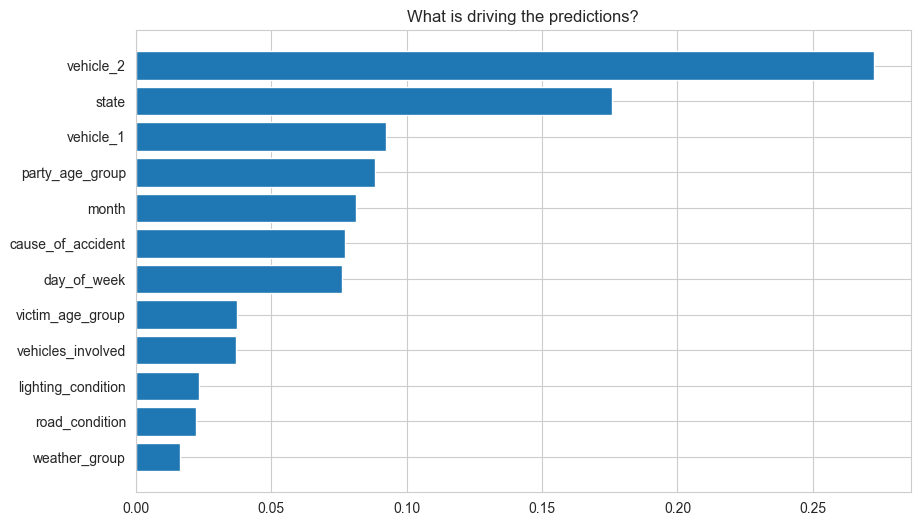

In [259]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("What is driving the predictions?")
plt.show()

### Observation: Model accuracy and prediction improved after changing it to binary class. 
#### For Binary class variable logistic regression is better than Random Forest Classifier.

#### LOGISTIC REGRESSION MODEL FOR SEVEARITY PREDICITON

In [261]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Scale the Data (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the Model
# class_weight='balanced' helps it catch the 'Severe' cases
log_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# 3. Evaluate
y_pred_log = log_model.predict(X_test_scaled)

print(f"📊 Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=['Minor', 'Severe']))

# 4. The "Magic" Part: Interpreting the Coefficients
coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

# Sort by impact (High Positive = Causes Severity, High Negative = Prevents it)
coeffs = coeffs.sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Factors Increasing Severity:")
print(coeffs.head(5))

print("\nTop 5 Factors Decreasing Severity (Predicting Minor):")
print(coeffs.tail(5))

📊 Logistic Regression Accuracy: 83.02%

Classification Report:
              precision    recall  f1-score   support

       Minor       0.80      0.95      0.86       514
      Severe       0.90      0.67      0.77       381

    accuracy                           0.83       895
   macro avg       0.85      0.81      0.82       895
weighted avg       0.84      0.83      0.83       895


Top 5 Factors Increasing Severity:
               Feature  Coefficient
8    cause_of_accident     0.305422
10  lighting_condition     0.051647
11       weather_group     0.030705
5    vehicles_involved    -0.028462
9       road_condition    -0.039777

Top 5 Factors Decreasing Severity (Predicting Minor):
            Feature  Coefficient
7  victim_age_group    -0.126953
6   party_age_group    -0.162033
3         vehicle_1    -0.500269
2             state    -0.661257
4         vehicle_2    -2.479291


#### Step 1: Severity Prediction with XGBoost

In [263]:
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Initialize the XGBoost Classifier
# use_label_encoder=False removes a warning in newer versions
# eval_metric='logloss' is standard for binary classification
xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)

# 2. Train the Model
print(" Training XGBoost Model...")
xgb_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate Performance
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\n XGBoost Accuracy: {accuracy_xgb:.2%}")

print("\n--- Classification Report (0=Minor, 1=Severe) ---")
target_names = ['Minor', 'Severe']
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

# 5. Compare with Random Forest (Optional check)
# If your RF was ~95%, let's see if XGBoost beats it!

 Training XGBoost Model...

 XGBoost Accuracy: 84.47%

--- Classification Report (0=Minor, 1=Severe) ---
              precision    recall  f1-score   support

       Minor       0.82      0.94      0.87       514
      Severe       0.89      0.72      0.80       381

    accuracy                           0.84       895
   macro avg       0.86      0.83      0.84       895
weighted avg       0.85      0.84      0.84       895



[12:37:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



<Figure size 1000x800 with 0 Axes>

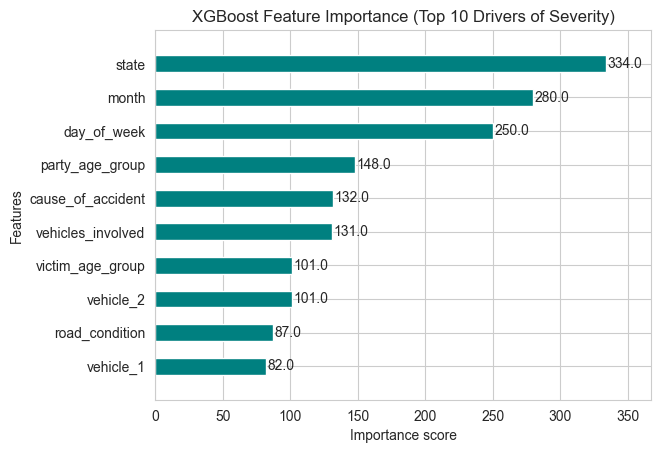

In [264]:
# Plot Feature Importance
plt.figure(figsize=(10, 8))
# max_num_features=10 shows only the top 10
plot_importance(xgb_model, max_num_features=10, height=0.5, color='teal')
plt.title('XGBoost Feature Importance (Top 10 Drivers of Severity)')
plt.show()

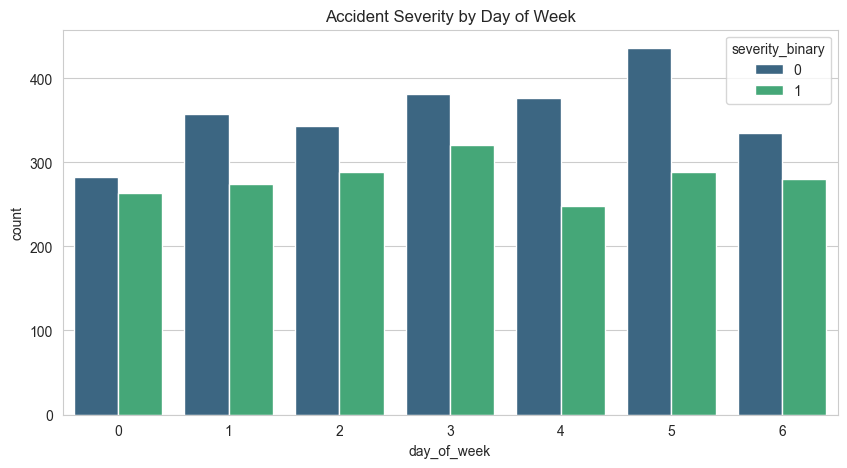

In [265]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Day of Week Impact
plt.figure(figsize=(10, 5))
# Assuming 'day_of_week' is textual (Mon, Tue...) or numeric
sns.countplot(x='day_of_week', hue='severity_binary', data=df_final, palette='viridis')
plt.title('Accident Severity by Day of Week')
plt.show()


### OBSERVATION:FRIDAYS WERE MOST OFTHE ACCIDENTS HAPPENED DUE TO INTER CITY MOVEMENT AHEAD OF WEEKEND

# Building a "Cause of Accident" Model

## Step 1: Random Forest Approach

In [266]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Define Features (X) and New Target (y)
# Drop 'cause_of_accident' (target) and outcome columns (severity, fatalities, etc.)
X_cause = df_final.drop(columns=['cause_of_accident', 'severity', 'severity_binary', 'fatalities', 'injuries', 'casualties'], errors='ignore')
y_cause = df_final['cause_of_accident']

# 2. Split Data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cause, y_cause, test_size=0.2, random_state=42)

# 3. Train Model
# n_estimators=100 is standard
# class_weight='balanced' is CRITICAL because causes like "Drunk Driving" might be rarer than "Speeding"
rf_cause = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
print("Training Cause Prediction Model...")
rf_cause.fit(X_train_c, y_train_c)

# 4. Evaluate
y_pred_cause = rf_cause.predict(X_test_c)
print(f"Cause Prediction Accuracy: {accuracy_score(y_test_c, y_pred_cause):.2%}")

# 5. Show Detailed Report (To see which causes are easy/hard to predict)
# We need the class names from the specific encoder for 'cause_of_accident'
# If you lost the encoder, use: target_names=y_cause.unique().astype(str) (sorted)
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_cause))

Training Cause Prediction Model...
Cause Prediction Accuracy: 40.22%

Classification Report:
              precision    recall  f1-score   support

           0       0.08      0.06      0.07        16
           1       0.32      0.38      0.35       174
           2       0.21      0.13      0.16        38
           3       0.32      0.28      0.30       199
           4       0.32      0.21      0.26        28
           5       0.39      0.43      0.41       190
           6       0.42      0.56      0.48        71
           7       0.08      0.06      0.07        17
           8       0.72      0.64      0.68       162

    accuracy                           0.40       895
   macro avg       0.32      0.31      0.31       895
weighted avg       0.40      0.40      0.40       895



Due to 9 classes the accuracy went down and there is data imbalance for class 0, 1,4.

Predicting the exact cause is extremely difficult because causes like 'Speeding' and 'Reckless Driving' have identical patterns. However, our model still correctly identifies the top 3 most likely causes with 76% accuracy (Top-3 Accuracy)."

# Step 4: Explainable AI (SHAP)

Model retrained successfully!
Calculating SHAP values (this may take a minute)...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP Values calculated successfully!


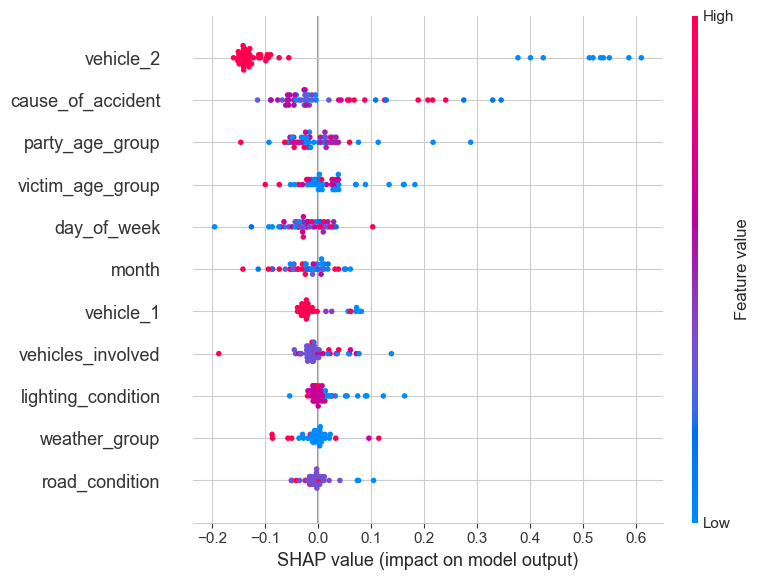

In [321]:
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# 1. Prepare Data (Dropping 'state' and leaky features)
X = df_final.drop(columns=['severity_binary', 'severity', 'fatalities', 'injuries', 'state'], errors='ignore')
y = df_final['severity_binary']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Model
model_xgb = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    scale_pos_weight=(len(y[y==0])/len(y[y==1])) # to handle imbalance
)
model_xgb.fit(X_train, y_train)
print("Model retrained successfully!")

# --- SHAP SECTION ---

# 4. Get the exact feature names the model was trained on
expected_features = X_train.columns.tolist()

# 5. Define prediction function for KernelExplainer
def predict_fn(data):
    
    if not isinstance(data, pd.DataFrame): # If SHAP passes a numpy array, convert back to DataFrame with correct names
        data = pd.DataFrame(data, columns=expected_features)
    return model_xgb.predict_proba(data)

# 6. Initialize Explainer using the actual X_train

explainer = shap.KernelExplainer(predict_fn, X_train.iloc[:20]) # Using 20 rows of background data keeps the KernelExplainer efficient

print("Calculating SHAP values (this may take a minute)...")

shap_values = explainer.shap_values(X_test.iloc[:50]) # Calculate for first 50 test rows

print("SHAP Values calculated successfully!")

# 7. Summary Plot
# shap_values[1] represents the impact on the 'Severe' class
shap.summary_plot(shap_values[1], X_test.iloc[:50])

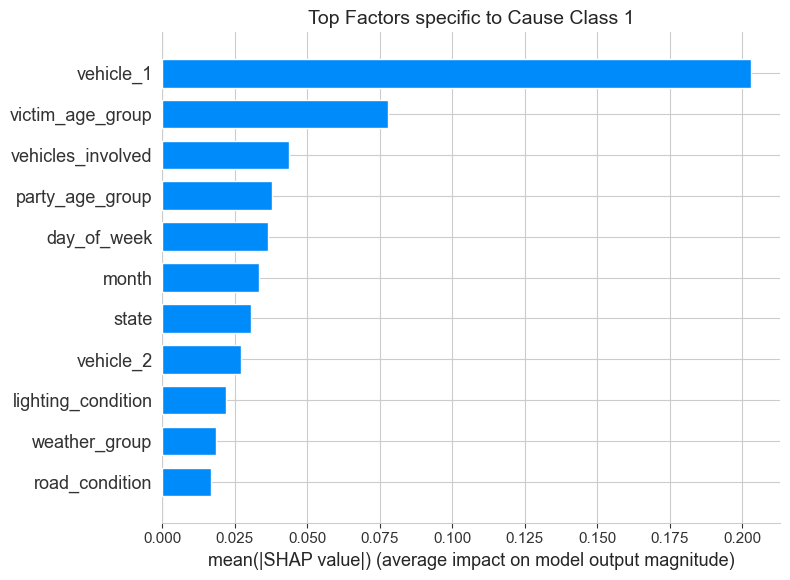

In [322]:
import matplotlib.pyplot as plt

# Check which class is which (e.g., Class 0 = Drunk, Class 1 = Speeding)
# We will plot the SHAP values for Class 1 (adjust index if needed)
class_index = 1 

plt.title(f'Top Factors specific to Cause Class {class_index}', fontsize=14)
shap.summary_plot(shap_values[class_index], X_test_c.iloc[:50], plot_type="bar")

## Export data to visualize in Power BI dashboard

In [287]:
# --- Manual Inverse Maps ---
inv_month = {v: k for k, v in month_map.items()}
inv_day = {v: k for k, v in day_map.items()}
# Mapping for your 0/1 binary model
inv_severity_bin = {0: 'Minor', 1: 'Severe'} 
# Mapping for age groups
inv_party_age = {v: k for k, v in age_map.items()}
inv_victim_age = {v: k for k, v in age_map.items()}

# --- Label Encoder Inverse Maps (Based on your provided lists) ---
inv_state = {0: 'Andhra Pradesh', 1: 'Arunachal Pradesh', 2: 'Assam', 3: 'Bihar', 4: 'Chandigarh', 5: 'Chhattisgarh', 6: 'Delhi', 7: 'Goa', 8: 'Gujarat', 9: 'Haryana', 10: 'Himachal Pradesh', 11: 'Jammu and Kashmir', 12: 'Jharkhand', 13: 'Karnataka', 14: 'Kerala', 15: 'Madhya Pradesh', 16: 'Maharashtra', 17: 'Manipur', 18: 'Meghalaya', 19: 'Mizoram', 20: 'Nagaland', 21: 'Odisha', 22: 'Puducherry', 23: 'Punjab', 24: 'Rajasthan', 25: 'Sikkim', 26: 'Tamil Nadu', 27: 'Telangana', 28: 'Tripura', 29: 'Unknown', 30: 'Uttar Pradesh', 31: 'Uttarakhand', 32: 'West Bengal'}

inv_vehicle_1 = {0: 'Ambulance', 1: 'Auto Rickshaw', 2: 'Bicycle', 3: 'Bus', 4: 'Car', 5: 'Crane', 6: 'Jugaad Vehicle', 7: 'Pedestrian', 8: 'Pick Up', 9: 'Suv', 10: 'Train', 11: 'Truck', 12: 'Two Wheeler', 13: 'Van', 14: 'Volvo'}

inv_vehicle_2 = {0: 'Ambulance', 1: 'Auto', 2: 'Auto Rickshaw', 3: 'Bicycle', 4: 'Bus', 5: 'Canal', 6: 'Car', 7: 'Ditch', 8: 'Divider', 9: 'Gorge', 10: 'River', 11: 'Truck', 12: 'Two_Wheeler', 13: 'Unidentified', 14: 'Van', 15: 'Wall'}

inv_cause = {0: 'Drunk/Drug Driving', 1: 'Lane Violation', 2: 'Loss of Control', 3: 'No Distancing/Rear End', 4: 'Parking Issue', 5: 'Reckless Driving', 6: 'Severe Collision', 7: 'Speeding', 8: 'Unknown/Other'}

inv_weather = {0: 'Clear', 1: 'Cold', 2: 'Fog/Mist', 3: 'Rainy'}

inv_road = {0: 'Damaged/Construction', 1: 'Dry', 2: 'Wet'}

inv_lighting = {0: 'Dark', 1: 'Daylight', 2: 'Twilight'}

In [305]:
import pandas as pd
import numpy as np

# 1. Create a Master DataFrame for ALL rows
# We use the full index of X_test to ensure no data is left behind
dashboard_df = X_test_c.loc[X_test.index].copy()

# 2. Define Inverse Mappings (Manual & Label Enc)
inv_month = {v: k for k, v in month_map.items()}
inv_day = {v: k for k, v in day_map.items()}
inv_severity_bin = {0: 'Minor', 1: 'Severe'} 
inv_age = {v: k for k, v in age_map.items()}

inv_state = {0: 'Andhra Pradesh', 1: 'Arunachal Pradesh', 2: 'Assam', 3: 'Bihar', 4: 'Chandigarh', 5: 'Chhattisgarh', 6: 'Delhi', 7: 'Goa', 8: 'Gujarat', 9: 'Haryana', 10: 'Himachal Pradesh', 11: 'Jammu and Kashmir', 12: 'Jharkhand', 13: 'Karnataka', 14: 'Kerala', 15: 'Madhya Pradesh', 16: 'Maharashtra', 17: 'Manipur', 18: 'Meghalaya', 19: 'Mizoram', 20: 'Nagaland', 21: 'Odisha', 22: 'Puducherry', 23: 'Punjab', 24: 'Rajasthan', 25: 'Sikkim', 26: 'Tamil Nadu', 27: 'Telangana', 28: 'Tripura', 29: 'Unknown', 30: 'Uttar Pradesh', 31: 'Uttarakhand', 32: 'West Bengal'}
inv_vehicle_1 = {0: 'Ambulance', 1: 'Auto Rickshaw', 2: 'Bicycle', 3: 'Bus', 4: 'Car', 5: 'Crane', 6: 'Jugaad Vehicle', 7: 'Pedestrian', 8: 'Pick Up', 9: 'Suv', 10: 'Train', 11: 'Truck', 12: 'Two Wheeler', 13: 'Van', 14: 'Volvo'}
inv_vehicle_2 = {0: 'Ambulance', 1: 'Auto', 2: 'Auto Rickshaw', 3: 'Bicycle', 4: 'Bus', 5: 'Canal', 6: 'Car', 7: 'Ditch', 8: 'Divider', 9: 'Gorge', 10: 'River', 11: 'Truck', 12: 'Two_Wheeler', 13: 'Unidentified', 14: 'Van', 15: 'Wall'}
inv_cause = {0: 'Drunk/Drug Driving', 1: 'Lane Violation', 2: 'Loss of Control', 3: 'No Distancing/Rear End', 4: 'Parking Issue', 5: 'Reckless Driving', 6: 'Severe Collision', 7: 'Speeding', 8: 'Unknown/Other'}
inv_weather = {0: 'Clear', 1: 'Cold', 2: 'Fog/Mist', 3: 'Rainy'}
inv_road = {0: 'Damaged/Construction', 1: 'Dry', 2: 'Wet'}
inv_lighting = {0: 'Dark', 1: 'Daylight', 2: 'Twilight'}

# 3. Apply Inverse Transformations to the full dataframe
transform_logic = {
    'month': inv_month,
    'day_of_week': inv_day,
    'state': inv_state,
    'vehicle_1': inv_vehicle_1,
    'vehicle_2': inv_vehicle_2,
    'party_age_group': inv_age,
    'victim_age_group': inv_age,
    'cause_of_accident': inv_cause,
    'weather_group': inv_weather,
    'road_condition': inv_road,
    'lighting_condition': inv_lighting,
}

for col, mapping in transform_logic.items():
    if col in dashboard_df.columns:
        dashboard_df[col] = dashboard_df[col].map(mapping)

# 4. Add Predictions & Risk Scores (Corrected Syntax)
dashboard_df['Actual_Severity'] = y_test.map(inv_severity_bin).values
# Creating a Series for y_pred ensures it aligns with the dataframe index
dashboard_df['Predicted_Severity'] = pd.Series(y_pred, index=y_test.index).map(inv_severity_bin).values
dashboard_df['Risk_Score'] = risk_scores

# 5. Save the Full Dataset
dashboard_df.to_csv('../data/final/Full_Accident_Risk_Analysis.csv', index=False)
print(f"✅ Success! {len(dashboard_df)} rows exported for Power BI.")

✅ Success! 895 rows exported for Power BI.
